# JEPA Surface-Feature Diagnostics

This notebook probes whether a frozen JEPA encoder linearly exposes simple sequence statistics and state-dependent Othello features across layers.

Use it for any JEPA experiment by changing the run-selection variables in the configuration cell, especially `JEPA_RUN_NAME` and, if needed, the checkpoint name/path.

Repository assumptions:
- Legal move count uses `OthelloBoardState.get_valid_moves()`, with implicit pass handling for the next effective side to move.
- `dataset.py::load_chunk` returns raw board-cell move lists, directly usable by `OthelloBoardState`.
- JEPA objectives expose `context_encoder`; diagnostics probe that frozen context encoder as the inner GPT encoder.


## 1. Mount Google Drive

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Configure Paths

In [27]:
from pathlib import Path
import os
import subprocess
import sys

# Single configuration cell: change these for another encoder checkpoint.
BOARD_SIZE = 8
JEPA_RUN_NAME = 'jepa_vicreg_b8_run_001_hard_disjoint'
N_TRAIN_CHUNKS = 20

PROJECT_ROOT_CANDIDATES = [
    Path('/content/drive/Othercomputers/MyLaptop/Master_Thesis_Code'),
    Path('/content/drive/MyDrive/Master_Thesis_Code'),
]
PROJECT_ROOT = next((p for p in PROJECT_ROOT_CANDIDATES if (p / 'pyproject.toml').exists()), PROJECT_ROOT_CANDIDATES[-1])
ARTIFACT_ROOT = Path('/content/drive/MyDrive/Master_Thesis_Artifacts')

DATA_CANDIDATES = [
    PROJECT_ROOT / 'data' / f'othello_{BOARD_SIZE}x{BOARD_SIZE}',
    ARTIFACT_ROOT / 'data' / f'othello_{BOARD_SIZE}x{BOARD_SIZE}',
]
DATA_DIR = next((p for p in DATA_CANDIDATES if p.exists()), DATA_CANDIDATES[0])

RUN_CANDIDATES = [
    PROJECT_ROOT / 'runs' / JEPA_RUN_NAME,
    ARTIFACT_ROOT / 'runs' / JEPA_RUN_NAME,
]
JEPA_OUT_DIR = next((p for p in RUN_CANDIDATES if p.exists()), RUN_CANDIDATES[0])
RUNS_DIR = JEPA_OUT_DIR.parent

assert PROJECT_ROOT.exists(), PROJECT_ROOT
assert DATA_DIR.exists(), DATA_DIR
assert JEPA_OUT_DIR.exists(), JEPA_OUT_DIR
DIAG_OUT_DIR = JEPA_OUT_DIR / 'diagnostics'
DIAG_OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', str(PROJECT_ROOT)], check=True)
os.chdir(PROJECT_ROOT)

all_chunks = sorted(DATA_DIR.glob('*.pickle'))
assert len(all_chunks) > N_TRAIN_CHUNKS, f'Need validation chunks after first {N_TRAIN_CHUNKS}: {DATA_DIR}'
train_chunks = all_chunks[:N_TRAIN_CHUNKS]
val_chunks = all_chunks[-5:]

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR    :', DATA_DIR)
print('RUNS_DIR    :', RUNS_DIR)
print('JEPA_OUT_DIR:', JEPA_OUT_DIR)
print('DIAG_OUT_DIR:', DIAG_OUT_DIR)
print('train chunks:', len(train_chunks), 'val chunks:', len(val_chunks))

PROJECT_ROOT: /content/drive/Othercomputers/MyLaptop/Master_Thesis_Code
DATA_DIR    : /content/drive/MyDrive/Master_Thesis_Artifacts/data/othello_8x8
RUNS_DIR    : /content/drive/MyDrive/Master_Thesis_Artifacts/runs
JEPA_OUT_DIR: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_vicreg_b8_run_001_hard_disjoint
DIAG_OUT_DIR: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_vicreg_b8_run_001_hard_disjoint/diagnostics
train chunks: 20 val chunks: 5


## 3. Pick Checkpoint

In [28]:
checkpoint_files = sorted(JEPA_OUT_DIR.glob('*.pt'))
print('Checkpoint dir:', JEPA_OUT_DIR)
print('Available checkpoint files:')
for path in checkpoint_files:
    print(' ', path.name)

CHECKPOINT_NAME = 'final.pt'
CHECKPOINT_PATH = JEPA_OUT_DIR / CHECKPOINT_NAME
if not CHECKPOINT_PATH.exists():
    assert checkpoint_files, f'No checkpoint files found in {JEPA_OUT_DIR}'
    CHECKPOINT_PATH = checkpoint_files[-1]
print('Selected:', CHECKPOINT_PATH)

Checkpoint dir: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_vicreg_b8_run_001_hard_disjoint
Available checkpoint files:
  checkpoint_games_001M.pt
  final.pt
  latest.pt
Selected: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_vicreg_b8_run_001_hard_disjoint/final.pt


## 4. Imports

In [29]:
import json
import math

import matplotlib.pyplot as plt
import torch

from othello_research.datasets.dataset import load_chunk
from othello_research.datasets.move_mapping import build_mappings
import othello_research.training.train_jepa as tjm
from othello_research.probes.surface_features import (
    FEATURE_SPECS,
    ProbeTrainConfig,
    extract_activations,
    run_surface_diagnostics,
)

print('imports OK')

imports OK


## 5. Restore Checkpoint And Load Model

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
jepa_model, jepa_cfg = tjm.build_model_from_checkpoint(ckpt)
state = ckpt['model']
load_mode = 'full_state_dict'

try:
    jepa_model.load_state_dict(state)
except RuntimeError as exc:
    # Legacy JEPA checkpoints before the unified objective refactor stored the
    # online encoder under `encoder.*` and may not contain target_encoder.* keys.
    # Surface diagnostics only probe the frozen online/context encoder, so load
    # that encoder directly and ignore predictor/target mismatches.
    if not any(key.startswith('encoder.') for key in state):
        raise
    encoder_state = {
        key.replace('encoder.', '', 1): value
        for key, value in state.items()
        if key.startswith('encoder.')
    }
    encoder = getattr(jepa_model, 'encoder', None)
    if encoder is None:
        encoder = jepa_model.context_encoder
    encoder.load_state_dict(encoder_state, strict=True)
    load_mode = 'legacy_encoder_only'

jepa_model.to(device)
jepa_model.eval()

encoder = getattr(jepa_model, 'encoder', None)
if encoder is None:
    encoder = jepa_model.context_encoder
encoder.to(device)
encoder.eval()

param_count = sum(p.numel() for p in encoder.parameters())
print('device     :', device)
print('checkpoint :', CHECKPOINT_PATH.name)
print('load mode  :', load_mode)
print('step       :', ckpt.get('step'))
print('games_seen :', f"{ckpt.get('games_seen', 0):,}")
print('encoder params:', f'{param_count:,}')
print('predictor  :', getattr(jepa_cfg, 'predictor_type', None))
print('horizon/EMA:', getattr(jepa_cfg, 'prediction_horizon', None), getattr(jepa_cfg, 'ema_momentum', None))


device     : cuda
checkpoint : final.pt
load mode  : full_state_dict
step       : 19550
games_seen : 4,999,952
encoder params: 25,312,768
predictor  : linear
horizon/EMA: 1 0.996


## 6. Sanity Check

In [31]:
raw_to_token, _ = build_mappings(BOARD_SIZE)
first_game = load_chunk(str(train_chunks[0]))[0]
seq_len = min(8, encoder.config.block_size, len(first_game))
tokens = [raw_to_token[int(move)] for move in first_game[:seq_len]]
x = torch.tensor([tokens], dtype=torch.long, device=device)
pos = torch.tensor([seq_len - 1], dtype=torch.long, device=device)
acts = extract_activations(encoder, x, pos, layers=(len(encoder.blocks),))
print('input shape             :', tuple(x.shape))
print('last hidden state shape :', tuple(acts[len(encoder.blocks)].shape))

input shape             : (1, 8)
last hidden state shape : (1, 512)


## 7. Configure Diagnostic Run

In [32]:
DIAG_TRAIN_GAMES = 5000
DIAG_VAL_GAMES = 500
DIAG_LAYERS = tuple(range(len(encoder.blocks) + 1))
DIAG_FEATURES = (
    'ply_index', 'parity', 'n_occupied', 'n_legal_moves',
    'last_move_position', 'corner_occupancy', 'edge_occupancy',
)
DIAG_SAMPLE_POSITIONS = 'one_per_game'

probe_cfg = ProbeTrainConfig(
    epochs=3,
    batch_size=256,
    lr=1e-3,
    weight_decay=0.0,
    device=str(device),
)

print('layers  :', DIAG_LAYERS)
print('features:', DIAG_FEATURES)
print('sample  :', DIAG_SAMPLE_POSITIONS)

layers  : (0, 1, 2, 3, 4, 5, 6, 7, 8)
features: ('ply_index', 'parity', 'n_occupied', 'n_legal_moves', 'last_move_position', 'corner_occupancy', 'edge_occupancy')
sample  : one_per_game


## 8. Run Diagnostics

In [33]:
results = run_surface_diagnostics(
    encoder=encoder,
    train_chunks=train_chunks,
    val_chunks=val_chunks,
    board_size=BOARD_SIZE,
    n_train_games=DIAG_TRAIN_GAMES,
    n_val_games=DIAG_VAL_GAMES,
    layers=DIAG_LAYERS,
    features=DIAG_FEATURES,
    sample_positions=DIAG_SAMPLE_POSITIONS,
    probe_cfg=probe_cfg,
    device=str(device),
)
print('diagnostics complete')

collect train activations:   0%|          | 0/20 [00:00<?, ?batch/s]

collect val activations:   0%|          | 0/2 [00:00<?, ?batch/s]

train linear probes:   0%|          | 0/63 [00:00<?, ?probe/s]

diagnostics complete


## 9. Results Table

In [24]:
def score_for(feature, layer):
    item = results['metrics'][feature][str(layer)]
    return float(item[item['metric']])

def metric_for(feature):
    first_layer = str(results['layers'][0])
    return results['metrics'][feature][first_layer]['metric']

header = 'feature(metric)'.ljust(30) + ''.join(f'L{layer:<7}' for layer in results['layers'])
print(header)
print('-' * len(header))
for feature in results['features']:
    label = f'{feature}({metric_for(feature)})'.ljust(30)
    values = ''.join(f'{score_for(feature, layer):<8.3f}' for layer in results['layers'])
    print(label + values)

feature(metric)               L0      L1      L2      L3      L4      L5      L6      L7      L8      
------------------------------------------------------------------------------------------------------
ply_index(r2)                 0.393   0.060   -2.139  -6.218  -12.819 -24.842 -68.164 -17.969 -38.198 
parity(accuracy)              0.770   0.572   0.536   0.518   0.524   0.526   0.536   0.532   0.522   
n_occupied(r2)                0.408   0.152   -2.180  -7.875  -9.214  -26.958 -74.760 -24.324 -78.097 
n_legal_moves(r2)             0.179   -0.241  -2.793  -5.067  -11.226 -42.548 -43.558 -26.646 -33.883 
last_move_position(accuracy)  0.970   0.062   0.074   0.070   0.048   0.032   0.030   0.044   0.014   
corner_occupancy(accuracy)    0.744   0.727   0.671   0.677   0.622   0.616   0.634   0.647   0.650   
edge_occupancy(accuracy)      0.638   0.585   0.555   0.552   0.550   0.545   0.557   0.540   0.531   


In [35]:
def score_for(feature, layer):
    item = results['metrics'][feature][str(layer)]
    return float(item[item['metric']])

def metric_for(feature):
    first_layer = str(results['layers'][0])
    return results['metrics'][feature][first_layer]['metric']

header = 'feature(metric)'.ljust(30) + ''.join(f'L{layer:<7}' for layer in results['layers'])
print(header)
print('-' * len(header))
for feature in results['features']:
    label = f'{feature}({metric_for(feature)})'.ljust(30)
    values = ''.join(f'{score_for(feature, layer):<8.3f}' for layer in results['layers'])
    print(label + values)

feature(metric)               L0      L1      L2      L3      L4      L5      L6      L7      L8      
------------------------------------------------------------------------------------------------------
ply_index(r2)                 0.206   0.800   0.490   -0.493  -0.109  -1.266  -0.276  -0.903  -3.022  
parity(accuracy)              0.848   0.560   0.526   0.550   0.564   0.524   0.528   0.548   0.476   
n_occupied(r2)                0.212   0.687   0.654   -0.391  0.275   -1.026  -2.202  -0.698  -2.360  
n_legal_moves(r2)             0.110   0.113   -0.348  -0.811  -1.121  -1.489  -1.586  -2.168  -2.848  
last_move_position(accuracy)  1.000   0.274   0.292   0.230   0.270   0.224   0.232   0.228   0.224   
corner_occupancy(accuracy)    0.744   0.763   0.767   0.747   0.733   0.740   0.698   0.723   0.764   
edge_occupancy(accuracy)      0.678   0.696   0.696   0.688   0.676   0.682   0.674   0.673   0.657   


## 10. Mean / Majority Baselines

These baselines use the same sampled train/validation positions as the JEPA diagnostics. Regression features predict the train-label mean and report validation R2. Classification features predict the train-set majority class; multi-group features use one majority class per group/cell and report aggregate validation accuracy.


In [25]:
from othello_research.probes.surface_features import (
    _load_games_from_chunks,
    _select_samples,
    compute_all_labels,
)

if 'score_for' not in globals():
    def score_for(feature, layer):
        item = results['metrics'][feature][str(layer)]
        return float(item[item['metric']])


def _collect_labels_for_samples(samples, board_size, features):
    label_lists = {feature: [] for feature in features}
    for game_raw, ply in samples:
        labels = compute_all_labels(game_raw, ply, board_size)
        for feature in features:
            label_lists[feature].append(labels[feature])
    return {feature: torch.stack(values, dim=0) for feature, values in label_lists.items()}


def _r2_against_constant(y_val, constant):
    y = y_val.float().view(-1)
    pred = torch.full_like(y, float(constant))
    ss_res = torch.sum((y - pred) ** 2)
    ss_tot = torch.sum((y - y.mean()) ** 2)
    if float(ss_tot.item()) == 0.0:
        return 0.0
    return 1.0 - float(ss_res.item() / ss_tot.item())


def _majority_class(y_train, n_classes=None):
    y = y_train.long().view(-1)
    if n_classes is None:
        n_classes = int(y.max().item()) + 1
    counts = torch.bincount(y, minlength=int(n_classes))
    return int(torch.argmax(counts).item()), counts


def _baseline_for_feature(feature, y_train, y_val):
    spec = FEATURE_SPECS[feature]
    probe_type = spec['type']
    if probe_type == 'regression':
        mean_value = float(y_train.float().view(-1).mean().item())
        return {
            'metric': 'r2',
            'r2': _r2_against_constant(y_val, mean_value),
            'prediction': mean_value,
            'n_labels': int(y_val.numel()),
            'baseline_type': 'train_mean',
        }

    if probe_type in {'binary', 'classification'}:
        n_classes = 2 if probe_type == 'binary' else BOARD_SIZE ** 2
        majority, train_counts = _majority_class(y_train, n_classes=n_classes)
        y = y_val.long().view(-1)
        accuracy = float((y == majority).float().mean().item())
        return {
            'metric': 'accuracy',
            'accuracy': accuracy,
            'prediction': majority,
            'train_majority_fraction': float(train_counts[majority].item() / max(1, y_train.numel())),
            'n_labels': int(y.numel()),
            'baseline_type': 'train_majority_class',
        }

    if probe_type == 'multi_classification':
        classes = int(spec['classes_per_group'])
        train = y_train.long()
        val = y_val.long()
        predictions = []
        train_majority_fractions = []
        for group_idx in range(train.size(1)):
            majority, counts = _majority_class(train[:, group_idx], n_classes=classes)
            predictions.append(majority)
            train_majority_fractions.append(float(counts[majority].item() / max(1, train.size(0))))
        pred = torch.tensor(predictions, dtype=torch.long).view(1, -1).expand_as(val)
        return {
            'metric': 'accuracy',
            'accuracy': float((val == pred).float().mean().item()),
            'exact_match': float((val == pred).all(dim=1).float().mean().item()),
            'predictions': predictions,
            'mean_train_majority_fraction': float(sum(train_majority_fractions) / len(train_majority_fractions)),
            'n_labels': int(val.numel()),
            'n_examples': int(val.size(0)),
            'baseline_type': 'train_majority_class_per_group',
        }

    raise ValueError(f'Unsupported feature type: {probe_type}')


baseline_train_games = _load_games_from_chunks(train_chunks, DIAG_TRAIN_GAMES)
baseline_val_games = _load_games_from_chunks(val_chunks, DIAG_VAL_GAMES)
baseline_train_samples = _select_samples(
    baseline_train_games, BOARD_SIZE, DIAG_SAMPLE_POSITIONS, seed=17
)
baseline_val_samples = _select_samples(
    baseline_val_games, BOARD_SIZE, DIAG_SAMPLE_POSITIONS, seed=29
)

baseline_train_labels = _collect_labels_for_samples(
    baseline_train_samples, BOARD_SIZE, DIAG_FEATURES
)
baseline_val_labels = _collect_labels_for_samples(
    baseline_val_samples, BOARD_SIZE, DIAG_FEATURES
)

baseline_results = {
    feature: _baseline_for_feature(
        feature, baseline_train_labels[feature], baseline_val_labels[feature]
    )
    for feature in DIAG_FEATURES
}
results['baselines'] = baseline_results

print('feature'.ljust(24), 'metric'.ljust(10), 'baseline'.rjust(10), 'best JEPA'.rjust(10), 'best layer'.rjust(10), 'gain'.rjust(10))
print('-' * 80)
for feature in DIAG_FEATURES:
    metric = baseline_results[feature]['metric']
    baseline_score = float(baseline_results[feature][metric])
    layer_scores = [(layer, score_for(feature, layer)) for layer in results['layers']]
    best_layer, best_score = max(layer_scores, key=lambda item: item[1])
    print(
        feature.ljust(24),
        metric.ljust(10),
        f'{baseline_score:10.3f}',
        f'{best_score:10.3f}',
        f'L{best_layer}'.rjust(10),
        f'{best_score - baseline_score:10.3f}',
    )


feature                  metric       baseline  best JEPA best layer       gain
--------------------------------------------------------------------------------
ply_index                r2             -0.000      0.393         L0      0.393
parity                   accuracy        0.540      0.770         L0      0.230
n_occupied               r2             -0.000      0.408         L0      0.408
n_legal_moves            r2             -0.000      0.179         L0      0.180
last_move_position       accuracy        0.022      0.970         L0      0.948
corner_occupancy         accuracy        0.753      0.744         L0     -0.010
edge_occupancy           accuracy        0.643      0.638         L0     -0.005


In [36]:
from othello_research.probes.surface_features import (
    _load_games_from_chunks,
    _select_samples,
    compute_all_labels,
)

if 'score_for' not in globals():
    def score_for(feature, layer):
        item = results['metrics'][feature][str(layer)]
        return float(item[item['metric']])


def _collect_labels_for_samples(samples, board_size, features):
    label_lists = {feature: [] for feature in features}
    for game_raw, ply in samples:
        labels = compute_all_labels(game_raw, ply, board_size)
        for feature in features:
            label_lists[feature].append(labels[feature])
    return {feature: torch.stack(values, dim=0) for feature, values in label_lists.items()}


def _r2_against_constant(y_val, constant):
    y = y_val.float().view(-1)
    pred = torch.full_like(y, float(constant))
    ss_res = torch.sum((y - pred) ** 2)
    ss_tot = torch.sum((y - y.mean()) ** 2)
    if float(ss_tot.item()) == 0.0:
        return 0.0
    return 1.0 - float(ss_res.item() / ss_tot.item())


def _majority_class(y_train, n_classes=None):
    y = y_train.long().view(-1)
    if n_classes is None:
        n_classes = int(y.max().item()) + 1
    counts = torch.bincount(y, minlength=int(n_classes))
    return int(torch.argmax(counts).item()), counts


def _baseline_for_feature(feature, y_train, y_val):
    spec = FEATURE_SPECS[feature]
    probe_type = spec['type']
    if probe_type == 'regression':
        mean_value = float(y_train.float().view(-1).mean().item())
        return {
            'metric': 'r2',
            'r2': _r2_against_constant(y_val, mean_value),
            'prediction': mean_value,
            'n_labels': int(y_val.numel()),
            'baseline_type': 'train_mean',
        }

    if probe_type in {'binary', 'classification'}:
        n_classes = 2 if probe_type == 'binary' else BOARD_SIZE ** 2
        majority, train_counts = _majority_class(y_train, n_classes=n_classes)
        y = y_val.long().view(-1)
        accuracy = float((y == majority).float().mean().item())
        return {
            'metric': 'accuracy',
            'accuracy': accuracy,
            'prediction': majority,
            'train_majority_fraction': float(train_counts[majority].item() / max(1, y_train.numel())),
            'n_labels': int(y.numel()),
            'baseline_type': 'train_majority_class',
        }

    if probe_type == 'multi_classification':
        classes = int(spec['classes_per_group'])
        train = y_train.long()
        val = y_val.long()
        predictions = []
        train_majority_fractions = []
        for group_idx in range(train.size(1)):
            majority, counts = _majority_class(train[:, group_idx], n_classes=classes)
            predictions.append(majority)
            train_majority_fractions.append(float(counts[majority].item() / max(1, train.size(0))))
        pred = torch.tensor(predictions, dtype=torch.long).view(1, -1).expand_as(val)
        return {
            'metric': 'accuracy',
            'accuracy': float((val == pred).float().mean().item()),
            'exact_match': float((val == pred).all(dim=1).float().mean().item()),
            'predictions': predictions,
            'mean_train_majority_fraction': float(sum(train_majority_fractions) / len(train_majority_fractions)),
            'n_labels': int(val.numel()),
            'n_examples': int(val.size(0)),
            'baseline_type': 'train_majority_class_per_group',
        }

    raise ValueError(f'Unsupported feature type: {probe_type}')


baseline_train_games = _load_games_from_chunks(train_chunks, DIAG_TRAIN_GAMES)
baseline_val_games = _load_games_from_chunks(val_chunks, DIAG_VAL_GAMES)
baseline_train_samples = _select_samples(
    baseline_train_games, BOARD_SIZE, DIAG_SAMPLE_POSITIONS, seed=17
)
baseline_val_samples = _select_samples(
    baseline_val_games, BOARD_SIZE, DIAG_SAMPLE_POSITIONS, seed=29
)

baseline_train_labels = _collect_labels_for_samples(
    baseline_train_samples, BOARD_SIZE, DIAG_FEATURES
)
baseline_val_labels = _collect_labels_for_samples(
    baseline_val_samples, BOARD_SIZE, DIAG_FEATURES
)

baseline_results = {
    feature: _baseline_for_feature(
        feature, baseline_train_labels[feature], baseline_val_labels[feature]
    )
    for feature in DIAG_FEATURES
}
results['baselines'] = baseline_results

print('feature'.ljust(24), 'metric'.ljust(10), 'baseline'.rjust(10), 'best JEPA'.rjust(10), 'best layer'.rjust(10), 'gain'.rjust(10))
print('-' * 80)
for feature in DIAG_FEATURES:
    metric = baseline_results[feature]['metric']
    baseline_score = float(baseline_results[feature][metric])
    layer_scores = [(layer, score_for(feature, layer)) for layer in results['layers']]
    best_layer, best_score = max(layer_scores, key=lambda item: item[1])
    print(
        feature.ljust(24),
        metric.ljust(10),
        f'{baseline_score:10.3f}',
        f'{best_score:10.3f}',
        f'L{best_layer}'.rjust(10),
        f'{best_score - baseline_score:10.3f}',
    )


feature                  metric       baseline  best JEPA best layer       gain
--------------------------------------------------------------------------------
ply_index                r2             -0.000      0.800         L1      0.800
parity                   accuracy        0.540      0.848         L0      0.308
n_occupied               r2             -0.000      0.687         L1      0.688
n_legal_moves            r2             -0.000      0.113         L1      0.113
last_move_position       accuracy        0.022      1.000         L0      0.978
corner_occupancy         accuracy        0.753      0.767         L2      0.014
edge_occupancy           accuracy        0.643      0.696         L2      0.053


## 11. Heatmap Visualization

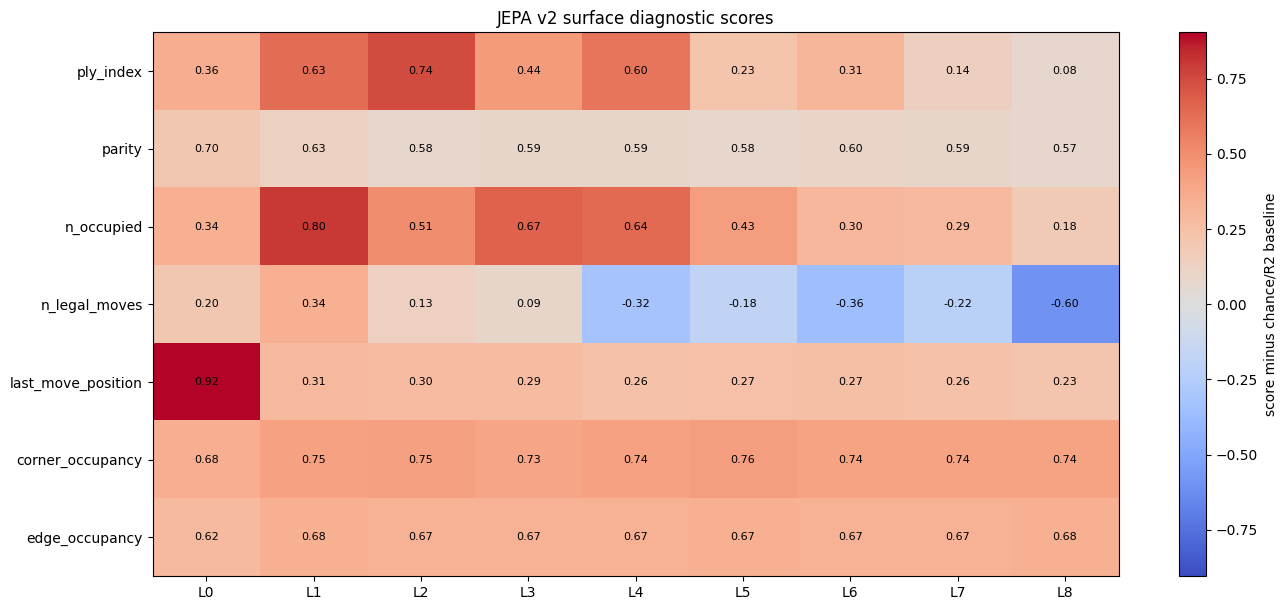

In [21]:
features = results['features']
layers = results['layers']
raw_scores = []
centered_scores = []
for feature in features:
    raw_row = []
    centered_row = []
    for layer in layers:
        item = results['metrics'][feature][str(layer)]
        score = float(item[item['metric']])
        selected = item['val'] if item.get('val') is not None else item['train']
        chance = float(selected.get('chance', 0.0))
        raw_row.append(score)
        centered_row.append(score - chance)
    raw_scores.append(raw_row)
    centered_scores.append(centered_row)

heat = torch.tensor(centered_scores).numpy()
raw = torch.tensor(raw_scores).numpy()
limit = max(abs(float(heat.min())), abs(float(heat.max())), 1e-6)

plt.figure(figsize=(1.2 * len(layers) + 3, 0.6 * len(features) + 2))
im = plt.imshow(heat, cmap='coolwarm', vmin=-limit, vmax=limit, aspect='auto')
plt.colorbar(im, label='score minus chance/R2 baseline')
plt.xticks(range(len(layers)), [f'L{layer}' for layer in layers])
plt.yticks(range(len(features)), features)
for i in range(len(features)):
    for j in range(len(layers)):
        plt.text(j, i, f'{raw[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('JEPA v2 surface diagnostic scores')
plt.tight_layout()
plt.show()

## 12. AR Transformer Surface Diagnostics

This runs the same probes on the AR Transformer baseline (`run_001`) using the same chunks, sampled positions, features, layers, and linear-probe hyperparameters. This is the key control for deciding whether JEPA v2 is specifically weak relative to the autoregressive baseline.


In [37]:
from othello_research.models.gpt import GPTConfig, OthelloGPT

AR_RUN_NAME = 'run_001'
AR_RUN_CANDIDATES = [
    PROJECT_ROOT / 'runs' / AR_RUN_NAME,
    ARTIFACT_ROOT / 'runs' / AR_RUN_NAME,
]
AR_OUT_DIR = next((p for p in AR_RUN_CANDIDATES if p.exists()), AR_RUN_CANDIDATES[0])
assert AR_OUT_DIR.exists(), AR_OUT_DIR

ar_checkpoint_files = sorted(AR_OUT_DIR.glob('*.pt'))
print('AR checkpoint dir:', AR_OUT_DIR)
print('Available AR checkpoint files:')
for path in ar_checkpoint_files:
    print(' ', path.name)

AR_CHECKPOINT_NAME = 'final.pt'
AR_CHECKPOINT_PATH = AR_OUT_DIR / AR_CHECKPOINT_NAME
if not AR_CHECKPOINT_PATH.exists():
    assert ar_checkpoint_files, f'No AR checkpoint files found in {AR_OUT_DIR}'
    AR_CHECKPOINT_PATH = ar_checkpoint_files[-1]
print('Selected AR checkpoint:', AR_CHECKPOINT_PATH)

# Free JEPA weights before loading AR to reduce T4 VRAM pressure.
try:
    del jepa_model
    del encoder
    if device.type == 'cuda':
        torch.cuda.empty_cache()
except NameError:
    pass

ar_ckpt = torch.load(AR_CHECKPOINT_PATH, map_location=device)
ar_cfg = GPTConfig(**ar_ckpt['model_config'])
ar_model = OthelloGPT(ar_cfg)
ar_model.load_state_dict(ar_ckpt['model'])
ar_model.to(device)
ar_model.eval()

print('AR checkpoint:', AR_CHECKPOINT_PATH.name)
print('AR step      :', ar_ckpt.get('step'))
print('AR games_seen:', f"{ar_ckpt.get('games_seen', 0):,}")
print('AR params    :', f"{sum(p.numel() for p in ar_model.parameters()):,}")


AR checkpoint dir: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/run_001
Available AR checkpoint files:
  checkpoint_games_001M.pt
  checkpoint_games_005M.pt
  checkpoint_games_010M.pt
  checkpoint_games_015M.pt
  final.pt
  latest.pt
Selected AR checkpoint: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/run_001/final.pt
AR checkpoint: final.pt
AR step      : 78200
AR games_seen: 19,999,840
AR params    : 25,312,768


In [38]:
ar_results = run_surface_diagnostics(
    encoder=ar_model,
    train_chunks=train_chunks,
    val_chunks=val_chunks,
    board_size=BOARD_SIZE,
    n_train_games=DIAG_TRAIN_GAMES,
    n_val_games=DIAG_VAL_GAMES,
    layers=DIAG_LAYERS,
    features=DIAG_FEATURES,
    sample_positions=DIAG_SAMPLE_POSITIONS,
    probe_cfg=probe_cfg,
    device=str(device),
)
ar_results['baselines'] = baseline_results
print('AR diagnostics complete')


collect train activations:   0%|          | 0/20 [00:00<?, ?batch/s]

collect val activations:   0%|          | 0/2 [00:00<?, ?batch/s]

train linear probes:   0%|          | 0/63 [00:00<?, ?probe/s]

AR diagnostics complete


feature                  metric       baseline  JEPA best   JEPA L    AR best     AR L    AR-JEPA
--------------------------------------------------------------------------------------------------
ply_index                r2             -0.000      0.800       L1      0.948       L1      0.147
parity                   accuracy        0.540      0.848       L0      0.996       L7      0.148
n_occupied               r2             -0.000      0.687       L1      0.957       L1      0.270
n_legal_moves            r2             -0.000      0.113       L1      0.575       L4      0.462
last_move_position       accuracy        0.022      1.000       L0      1.000       L0      0.000
corner_occupancy         accuracy        0.753      0.767       L2      0.958       L5      0.191
edge_occupancy           accuracy        0.643      0.696       L2      0.969       L5      0.273


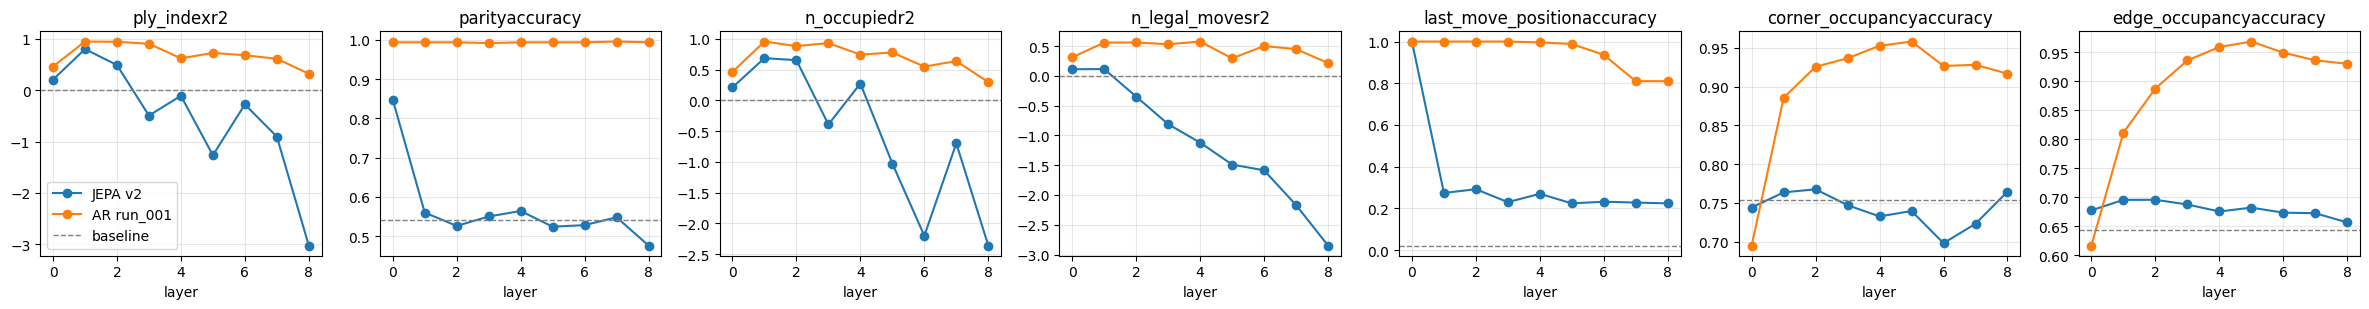

In [40]:
def ar_score_for(feature, layer):
    item = ar_results['metrics'][feature][str(layer)]
    return float(item[item['metric']])

print('feature'.ljust(24), 'metric'.ljust(10), 'baseline'.rjust(10), 'JEPA best'.rjust(10), 'JEPA L'.rjust(8), 'AR best'.rjust(10), 'AR L'.rjust(8), 'AR-JEPA'.rjust(10))
print('-' * 98)
for feature in DIAG_FEATURES:
    metric = baseline_results[feature]['metric']
    baseline_score = float(baseline_results[feature][metric])
    jepa_layer, jepa_best = max(
        ((layer, score_for(feature, layer)) for layer in results['layers']),
        key=lambda item: item[1],
    )
    ar_layer, ar_best = max(
        ((layer, ar_score_for(feature, layer)) for layer in ar_results['layers']),
        key=lambda item: item[1],
    )
    print(
        feature.ljust(24),
        metric.ljust(10),
        f'{baseline_score:10.3f}',
        f'{jepa_best:10.3f}',
        f'L{jepa_layer}'.rjust(8),
        f'{ar_best:10.3f}',
        f'L{ar_layer}'.rjust(8),
        f'{ar_best - jepa_best:10.3f}',
    )

fig, axes = plt.subplots(1, len(DIAG_FEATURES), figsize=(3.4 * len(DIAG_FEATURES), 3.2), sharey=False)
if len(DIAG_FEATURES) == 1:
    axes = [axes]
for ax, feature in zip(axes, DIAG_FEATURES):
    jepa_y = [score_for(feature, layer) for layer in results['layers']]
    ar_y = [ar_score_for(feature, layer) for layer in ar_results['layers']]
    metric = baseline_results[feature]['metric']
    baseline = float(baseline_results[feature][metric])
    ax.plot(results['layers'], jepa_y, marker='o', label='JEPA v2')
    ax.plot(ar_results['layers'], ar_y, marker='o', label='AR run_001')
    ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, label='baseline')
    ax.set_title(f'{feature}{metric}')
    ax.set_xlabel('layer')
    ax.grid(True, alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


In [ ]:
ar_result_path = DIAG_OUT_DIR / f'surface_diagnostics__AR_{AR_RUN_NAME}__{AR_CHECKPOINT_PATH.stem}.json'
ar_result_path.write_text(json.dumps(ar_results, indent=2, default=str), encoding='utf-8')
print('saved AR diagnostics:', ar_result_path)


## 13. Save JEPA Results

In [ ]:
results['baselines'] = baseline_results
result_path = DIAG_OUT_DIR / f'surface_diagnostics__{CHECKPOINT_PATH.stem}.json'
result_path.write_text(json.dumps(results, indent=2, default=str), encoding='utf-8')
print('saved JEPA diagnostics:', result_path)


saved: /content/drive/MyDrive/Master_Thesis_Artifacts/runs/jepa_transformer_b8_run_001/diagnostics/surface_diagnostics__final.json


## 14. Brief Interpretation

After running the notebook, compare every learned score against the mean/majority baseline and against the AR baseline.

> If JEPA v2 only beats the majority baseline weakly on `corner_occupancy` / `edge_occupancy`, while AR strongly beats the same baselines across depth, this supports the shortcut hypothesis. Fill in the observed deltas after running: JEPA surface features {X}; JEPA state features over baseline {Y}; AR state features over baseline {Z}.
